# C++ Berry-INLA version

In [1]:
import sys
sys.path.append('../../research/berry/')
import util

import fast_inla
from scipy.special import logit, expit
import matplotlib.pyplot as plt
import numpy as np
from pykevlar.core import mt19937
from pykevlar.grid import HyperPlane
from pykevlar.driver import accumulate_process
import pykevlar.core.model.binomial
from utils import make_cartesian_grid_range

/Users/tbent/.mambaforge/envs/kevlar/lib/python3.10/site-packages/jax/_src/lib/__init__.py:33: UserWarning: JAX on Mac ARM machines is experimental and minimally tested. Please see https://github.com/google/jax/issues/5501 in the event of problems.
  warnings.warn("JAX on Mac ARM machines is experimental and minimally tested. "


In [2]:
fi = fast_inla.FastINLA(2)

n_arms = 2
model_type_name = 'BerryINLA' + str(n_arms)
model_type = getattr(pykevlar.core.model.binomial, model_type_name)
print(model_type)
seed = 10
n_theta_1d = 16
sim_size = 1000
n_threads = 1

# define null hypos
null_hypos = []
for i in range(n_arms):
    n = np.zeros(n_arms)
    # null is:
    # theta_i <= logit(0.1)
    # the normal should point towards the negative direction. but that also
    # means we need to negate the logit(0.1) offset
    n[i] = -1
    null_hypos.append(HyperPlane(n, -logit(0.1)))

gr = make_cartesian_grid_range(n_theta_1d, np.full(n_arms, -3.5), np.full(n_arms, 1.0), sim_size)

2022-04-22 14:27:02 DEBUG    dispatch            : Finished tracing + transforming prim_fun for jit in 0.00018405914306640625 sec
2022-04-22 14:27:02 DEBUG    xla_bridge          : Initializing backend 'interpreter'
2022-04-22 14:27:02 DEBUG    xla_bridge          : Backend 'interpreter' initialized
2022-04-22 14:27:02 DEBUG    xla_bridge          : Initializing backend 'cpu'
2022-04-22 14:27:02 DEBUG    xla_bridge          : Backend 'cpu' initialized
2022-04-22 14:27:02 DEBUG    xla_bridge          : Initializing backend 'tpu_driver'
2022-04-22 14:27:02 INFO     xla_bridge          : Unable to initialize backend 'tpu_driver': NOT_FOUND: Unable to find driver in registry given worker: 
2022-04-22 14:27:02 DEBUG    xla_bridge          : Initializing backend 'gpu'
2022-04-22 14:27:02 INFO     xla_bridge          : Unable to initialize backend 'gpu': NOT_FOUND: Could not find registered platform with name: "cuda". Available platform names are: Host Interpreter
2022-04-22 14:27:02 DEBUG   

<class 'pykevlar.core.model.binomial.BerryINLA2'>


Red dots are points in the alternative hypothesis space.
Blue dots are points in the null space.

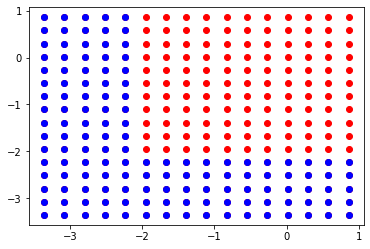

In [3]:
gr.create_tiles(null_hypos)
plt.plot(gr.thetas()[0,:], gr.thetas()[1,:], 'ro')
gr.prune()
plt.plot(gr.thetas()[0,:], gr.thetas()[1,:], 'bo')
plt.show()

Run a single example set of data and make sure that the kevlar model is producing the sample results as the prototype FastINLA code.

In [5]:
y = np.array([[4, 5]])
n = np.array([[35, 35]])
critical_values = [0.85] # final analysis exceedance requirement (note for interim analysis, the threshold)
b = model_type(
    n[0,0],
    critical_values,
    np.full(2, fi.thresh_theta),
    fi.sigma2_rule.wts.copy(),
    fi.cov.reshape((-1, 4)).T.copy(),
    fi.neg_precQ.reshape((-1, 4)).T.copy(),
    fi.logprecQdet.copy(),
    fi.log_prior.copy(),
    fi.tol,
    fi.logit_p1
)
correct = fi.numpy_inference(y, n)[1][0]
exc = b.get_posterior_exceedance_probs(y[0])
np.testing.assert_allclose(exc, correct)

In [6]:
import time
start = time.time()
out = accumulate_process(b, gr, sim_size, seed, n_threads)
end = time.time()
print('runtime', end - start)

runtime 4.115777015686035


In [14]:
theta = gr.thetas().T.copy()
theta_tiles = np.repeat(theta, np.array(gr.n_tiles_per_pt), axis=0)

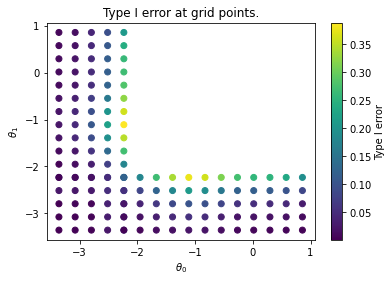

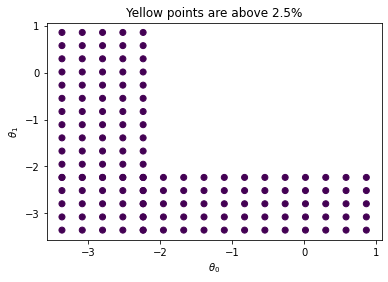

In [17]:
plt.figure()
plt.title('Type I error at grid points.')
plt.scatter(theta_tiles[:,0], theta_tiles[:,1], c=out.typeI_sum()[0] / sim_size)
cbar = plt.colorbar()
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
cbar.set_label('Type I error')
plt.show()
plt.title('Yellow points are above 2.5%')
plt.scatter(theta_tiles[:,0], theta_tiles[:,1], c=out.typeI_sum()[0] > 0.025)
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.show()

# Python re-implementation of accumulation

In [8]:
%%time
theta = gr.thetas().T.copy()
theta_tiles = np.repeat(theta, np.array(gr.n_tiles_per_pt), axis=0)
p_tiles = expit(theta_tiles)

# Use the mt19937 object exported from C++ so that we can match the C++ random
# sequence exactly. This is not necessary in the long term but is temporarily
# useful to ensure that this code is producing identical output to the C++
# version.
n_arm_samples = 35
gen = mt19937(seed)

# We flip the order of n_arms and n_arm_samples here so the random number
# generator produces the same sequence of uniforms as are used in the C++ kevlar
# internals. The Kevlar function operates in column-major/Fortran order. Whereas
# here, numpy operates in row-major/C ordering b
samples = np.empty((sim_size, n_arms, n_arm_samples))
gen.uniform_sample(samples.ravel())

# after transposing, samples will have shape (sim_size, n_arm_samples, n_arms)
samples = np.transpose(samples, (0, 2, 1))

# sufficient statistic for binomial is just the number of draws above the
# threshold probability. But the `p` array has shape (n_thetas, n_arms). So, we
# add empty dimensions to broadcast to an output `y` array of shape: 
# (n_thetas, sim_size, n_arm_samples, n_arms)
y = np.sum(samples[None] < p_tiles[:, None, None, :], axis=2)

CPU times: user 79 ms, sys: 2.27 ms, total: 81.3 ms
Wall time: 28.9 ms


In [9]:
%%time
# Calculate exceedance from each simulated sample.
y_flat = y.reshape((-1, 2))
n_flat = np.full_like(y_flat, n_arm_samples)
_, exceedance_flat, _ = fi.jax_inference(y_flat, n_flat)
exceedance = exceedance_flat.to_py().reshape(y.shape)

2022-04-22 14:27:09 DEBUG    dispatch            : Finished tracing + transforming prim_fun for jit in 0.0001761913299560547 sec
2022-04-22 14:27:09 DEBUG    dispatch            : Finished tracing + transforming jax_opt for jit in 0.03876781463623047 sec
2022-04-22 14:27:09 DEBUG    dispatch            : Compiling jax_opt (5029720320 for args (ShapedArray(int64[145000,2]), ShapedArray(int64[145000,2]), ShapedArray(float64[15,2,2]), ShapedArray(float64[15,2,2]), ShapedArray(float64[]), ShapedArray(float64[], weak_type=True), ShapedArray(float64[], weak_type=True)).
2022-04-22 14:27:09 DEBUG    dispatch            : Finished XLA compilation of jax_opt in 0.14560174942016602 sec
2022-04-22 14:27:10 DEBUG    dispatch            : Finished tracing + transforming jax_calc_posterior_and_exceedances for jit in 0.01446390151977539 sec
2022-04-22 14:27:10 DEBUG    dispatch            : Compiling jax_calc_posterior_and_exceedances (5084067808) for 11 args.
2022-04-22 14:27:10 DEBUG    dispatch   

CPU times: user 1.47 s, sys: 90.3 ms, total: 1.56 s
Wall time: 668 ms


In [52]:
%%time
# Determine type I error. 
# 1. success is defined by whether the exceedance probability exceeds the critical value
# 2. type I is only possible when the null hypothesis is true. 
# 3. check all null hypotheses.
# 4. sum across all the simulations.
success = exceedance > critical_values[0]
is_null_per_arm = np.array([[gr.check_null(i, j) for j in range(n_arms)] for i in range(p_tiles.shape[0])])
false_reject = success & is_null_per_arm[:, None,]
any_rejection = np.any(false_reject, axis=-1)
typeI_sum = any_rejection.sum(axis=-1)


CPU times: user 5.83 ms, sys: 1.32 ms, total: 7.16 ms
Wall time: 5.87 ms


In [ ]:

# The score function is the primary component of the typeI gradient:
# 1. for binomial, it's just: y - n * p
# 2. only summed when there is a rejection in the given simulation
score = y - n_arm_samples * p_tiles[:, None, :]
typeI_score = np.sum(any_rejection[:, :, None] * score, axis=1)

Confirm that Kevlar and this Python code produce the same output.

In [49]:
typeI_good = np.all(out.typeI_sum() == typeI)
score_good = np.all(out.score_sum().reshape((-1, 2)) == typeI_score)
typeI_good, score_good

(True, True)

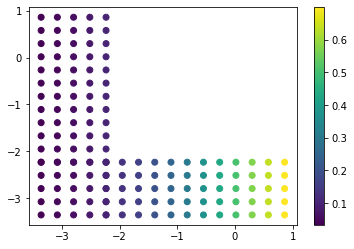

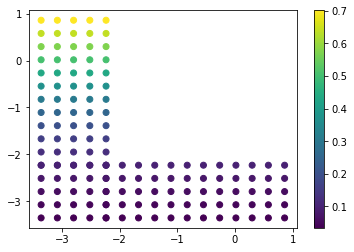

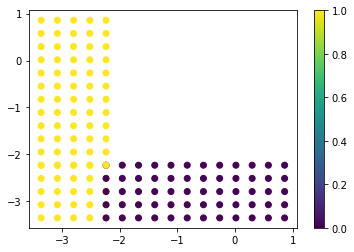

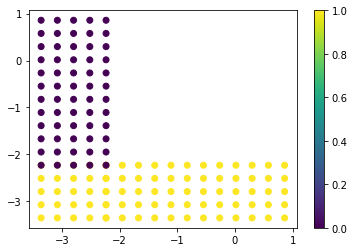

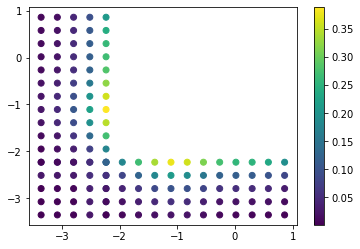

In [50]:
y_avg = np.mean(y, axis=1)
plt.scatter(theta_tiles[:,0], theta_tiles[:,1], c=y_avg[:,0] / n_arm_samples)
plt.colorbar()
plt.show()
plt.scatter(theta_tiles[:,0], theta_tiles[:,1], c=y_avg[:,1] / n_arm_samples)
plt.colorbar()
plt.show()

plt.scatter(theta_tiles[:,0], theta_tiles[:,1], c=is_null_per_arm[:,0])
plt.colorbar()
plt.show()
plt.scatter(theta_tiles[:,0], theta_tiles[:,1], c=is_null_per_arm[:,1])
plt.colorbar()
plt.show()

typeI_frac = typeI_sum / sim_size
plt.scatter(theta_tiles[:,0], theta_tiles[:,1], c=typeI_frac)
plt.colorbar()
plt.show()

# Trying to set up a Python Kevlar Model.

In [1]:
import sys
sys.path.append('../../research/berry/')

In [2]:
import fast_inla
import numpy as np

/Users/tbent/.mambaforge/envs/kevlar/lib/python3.10/site-packages/jax/_src/lib/__init__.py:33: UserWarning: JAX on Mac ARM machines is experimental and minimally tested. Please see https://github.com/google/jax/issues/5501 in the event of problems.
  warnings.warn("JAX on Mac ARM machines is experimental and minimally tested. "


In [17]:
from pykevlar.core.model import ModelBase, SimGlobalStateBase, SimStateBase
from pykevlar.core.model.binomial import SimpleSelection, SimpleSelectionSimGlobalState, SimpleSelectionSimState


class KevlarBerryINLA(SimpleSelection):
    def __init__(self, n_arms, n_arm_samples, gr):
        super().__init__(n_arms, n_arm_samples, 0, [2.1])
        # self.critical_values([2.1])
        self.gr = gr

class SGS(SimGlobalStateBase):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def make_sim_state(self):
        print("making sim state")
        return SS(self.model)

class SS(SimStateBase):
    def __init__(self, model):
        self.model = model

    def simulate(self, gen, rej_len):
        print(gen, rej_len)
        return None


class BS(SimpleSelectionSimState):
    pass

In [19]:
SimpleSelectionSimState()

TypeError: pykevlar.core.model.binomial.SimpleSelectionSimState: No constructor defined!

In [12]:
n_arms = 2
arm_samples = 35
n_sims = 10
seed = 10

In [13]:
from pykevlar.grid import HyperPlane

# define null hypos
null_hypos = []
for i in range(1, n_arms):
    n = np.zeros(n_arms)
    n[0] = 1
    n[i] = -1
    null_hypos.append(HyperPlane(n, 0))

from utils import make_cartesian_grid_range

gr = make_cartesian_grid_range(3, np.full(n_arms, -0.5), np.full(n_arms, 0.5), 1000)
gr.create_tiles(null_hypos)
gr.prune()

In [14]:
from pykevlar.core.driver import accumulate
from pykevlar.core.bound import TypeIErrorAccum
model = KevlarBerryINLA(n_arms, arm_samples, gr)
sgs = SGS(model)

In [15]:
# prepare output
acc_o = TypeIErrorAccum(
    model.n_models(),
    gr.n_tiles(),
    gr.n_params()
)

model.simulate()
acc_o.update(rej_len, )

In [16]:

# run C++ core routine
accumulate(
    sim_global_state=sgs,
    grid_range=gr,
    accum=acc_o,
    sim_size=n_sims,
    seed=10,
    n_threads=1
)

HI
HI
HI
